In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


**Load the Dataset**

In [2]:
import pandas as pd

file_path = r"C:\Retail supply chain\Data\DataCoSupplyChainDataset.csv"
df = pd.read_csv(file_path, encoding='ISO-8859-1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


**DataSet overview**

In [3]:
df.shape

(180519, 53)

In [4]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

In [6]:
df.info

<bound method DataFrame.info of             Type  Days for shipping (real)  Days for shipment (scheduled)  \
0          DEBIT                         3                              4   
1       TRANSFER                         5                              4   
2           CASH                         4                              4   
3          DEBIT                         3                              4   
4        PAYMENT                         2                              4   
...          ...                       ...                            ...   
180514      CASH                         4                              4   
180515     DEBIT                         3                              2   
180516  TRANSFER                         5                              4   
180517   PAYMENT                         3                              4   
180518   PAYMENT                         4                              4   

        Benefit per order  Sales per custom

In [7]:
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [8]:
df.columns = df.columns.str.replace(" ", "_")

In [9]:
df

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


In [10]:
df['shipping_date_(DateOrders)'] =pd.to_datetime(df['shipping_date_(DateOrders)'])
df


,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Description,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class


In [11]:
df.drop(columns=['Product_Description'], inplace=True)
df

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,CLOSED,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,COMPLETE,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,PENDING,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,PENDING_PAYMENT,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class


In [12]:
df['Customer_Lname'].fillna("Unknown", inplace=True)
df

C:\Users\Harika\AppData\Local\Temp\ipykernel_15120\1922457306.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer_Lname'].fillna("Unknown", inplace=True)


,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_Status,Order_Zipcode,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,CLOSED,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,COMPLETE,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,PENDING,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,PENDING_PAYMENT,NaN,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class


In [13]:
df['Order_Zipcode'].isnull().sum()

np.int64(155679)

In [14]:
df.drop(columns=['Order_Zipcode'], inplace=True)

In [15]:
df

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class


In [16]:
df.columns

Index(['Type', 'Days_for_shipping_(real)', 'Days_for_shipment_(scheduled)',
       'Benefit_per_order', 'Sales_per_customer', 'Delivery_Status',
       'Late_delivery_risk', 'Category_Id', 'Category_Name', 'Customer_City',
       'Customer_Country', 'Customer_Email', 'Customer_Fname', 'Customer_Id',
       'Customer_Lname', 'Customer_Password', 'Customer_Segment',
       'Customer_State', 'Customer_Street', 'Customer_Zipcode',
       'Department_Id', 'Department_Name', 'Latitude', 'Longitude', 'Market',
       'Order_City', 'Order_Country', 'Order_Customer_Id',
       'order_date_(DateOrders)', 'Order_Id', 'Order_Item_Cardprod_Id',
       'Order_Item_Discount', 'Order_Item_Discount_Rate', 'Order_Item_Id',
       'Order_Item_Product_Price', 'Order_Item_Profit_Ratio',
       'Order_Item_Quantity', 'Sales', 'Order_Item_Total',
       'Order_Profit_Per_Order', 'Order_Region', 'Order_State', 'Order_Status',
       'Product_Card_Id', 'Product_Category_Id', 'Product_Image',
       'Product_Na

In [17]:
df.drop(columns=['Customer_Email','Customer_Password','Customer_Street'], inplace=True)

In [18]:
df

,Type,Days_for_shipping_(real),Days_for_shipment_(scheduled),Benefit_per_order,Sales_per_customer,Delivery_Status,Late_delivery_risk,Category_Id,Category_Name,Customer_City,...,Order_State,Order_Status,Product_Card_Id,Product_Category_Id,Product_Image,Product_Name,Product_Price,Product_Status,shipping_date_(DateOrders),Shipping_Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,Rajastán,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,Rajastán,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,Shanghái,CLOSED,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,Osaka,COMPLETE,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,Australia del Sur,PENDING,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,Australia del Sur,PENDING_PAYMENT,1004,45,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class


In [19]:
df.duplicated().sum()

np.int64(0)

In [31]:
df.dtypes

Type                                     object
Days_for_shipping_(real)                  int64
Days_for_shipment_(scheduled)             int64
Benefit_per_order                       float64
Sales_per_customer                      float64
Delivery_Status                          object
Late_delivery_risk                        int64
Category_Id                               int64
Category_Name                            object
Customer_City                            object
Customer_Country                         object
Customer_Fname                           object
Customer_Id                               int64
Customer_Lname                           object
Customer_Segment                         object
Customer_State                           object
Customer_Zipcode                        float64
Department_Id                             int64
Department_Name                          object
Latitude                                float64
Longitude                               

In [20]:
df.columns = df.columns.str.lower()\
                       .str.replace(' ', '_')\
                       .str.replace('(', '')\
                       .str.replace(')', '')

In [21]:
df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])

In [22]:
df['customer_zipcode'] = df['customer_zipcode'].astype('Int64').astype(str)

In [23]:
df.isnull().sum()

type                           0
days_for_shipping_real         0
days_for_shipment_scheduled    0
benefit_per_order              0
sales_per_customer             0
delivery_status                0
late_delivery_risk             0
category_id                    0
category_name                  0
customer_city                  0
customer_country               0
customer_fname                 0
customer_id                    0
customer_lname                 0
customer_segment               0
customer_state                 0
customer_zipcode               0
department_id                  0
department_name                0
latitude                       0
longitude                      0
market                         0
order_city                     0
order_country                  0
order_customer_id              0
order_date_dateorders          0
order_id                       0
order_item_cardprod_id         0
order_item_discount            0
order_item_discount_rate       0
order_item

In [24]:
df.drop(columns=['product_image'], inplace=True)

In [25]:
df.drop(columns=['order_customer_id', 'product_category_id'], inplace=True)

In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
df['delivery_delay'] = df['days_for_shipping_real'] - df['days_for_shipment_scheduled']

In [28]:
df['is_profitable'] = df['order_profit_per_order'] > 0

In [29]:
df['profit_margin'] = df['order_profit_per_order'] / df['sales']

In [30]:
df

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_status,product_card_id,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,delivery_delay,is_profitable,profit_margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,1360,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class,-1,True,0.278413
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,1360,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class,1,False,-0.760000
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,1360,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class,0,False,-0.756003
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,1360,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class,-1,True,0.069748
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,1360,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class,-2,True,0.409489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,CLOSED,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class,0,True,0.100005
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,COMPLETE,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class,1,False,-1.534502
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,PENDING,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class,1,True,0.352793
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,PENDING_PAYMENT,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class,-1,True,0.465598


In [31]:
df.to_csv("cleaned_supply_chain.csv", index=False)

In [32]:
df

,type,days_for_shipping_real,days_for_shipment_scheduled,benefit_per_order,sales_per_customer,delivery_status,late_delivery_risk,category_id,category_name,customer_city,...,order_status,product_card_id,product_name,product_price,product_status,shipping_date_dateorders,shipping_mode,delivery_delay,is_profitable,profit_margin
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,COMPLETE,1360,Smart watch,327.750000,0,2018-02-03 22:56:00,Standard Class,-1,True,0.278413
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,PENDING,1360,Smart watch,327.750000,0,2018-01-18 12:27:00,Standard Class,1,False,-0.760000
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,CLOSED,1360,Smart watch,327.750000,0,2018-01-17 12:06:00,Standard Class,0,False,-0.756003
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,COMPLETE,1360,Smart watch,327.750000,0,2018-01-16 11:45:00,Standard Class,-1,True,0.069748
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,PENDING_PAYMENT,1360,Smart watch,327.750000,0,2018-01-15 11:24:00,Standard Class,-2,True,0.409489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,CLOSED,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 03:40:00,Standard Class,0,True,0.100005
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,COMPLETE,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-19 01:34:00,Second Class,1,False,-1.534502
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,PENDING,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-20 21:00:00,Standard Class,1,True,0.352793
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,PENDING_PAYMENT,1004,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,2016-01-18 20:18:00,Standard Class,-1,True,0.465598


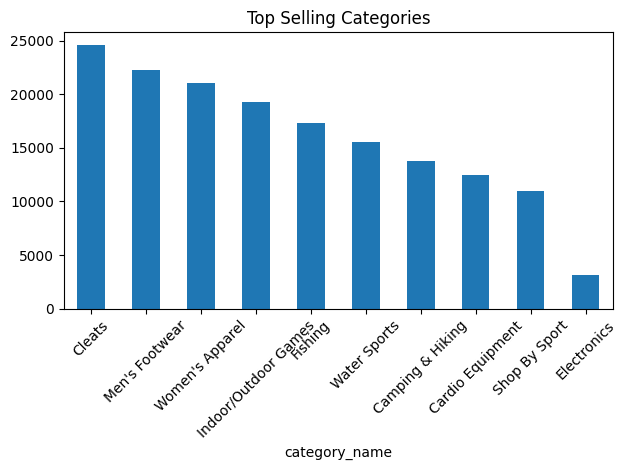

In [33]:
df['category_name'].value_counts().head(10).plot(kind='bar')
plt.title('Top Selling Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

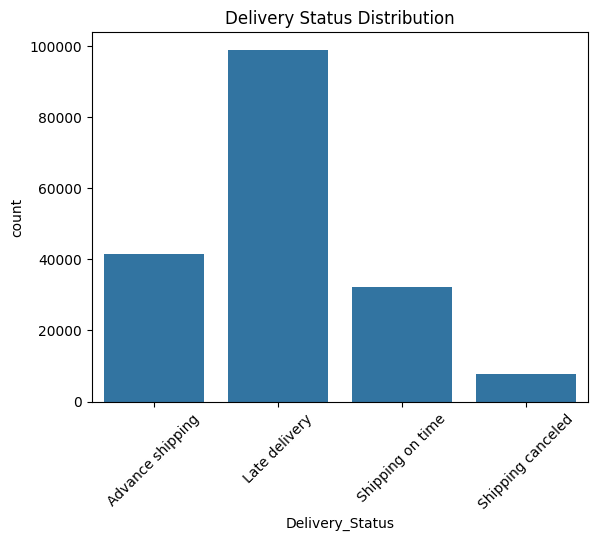

In [6]:
sns.countplot(x='delivery_status', data=df)
plt.title('Delivery Status Distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

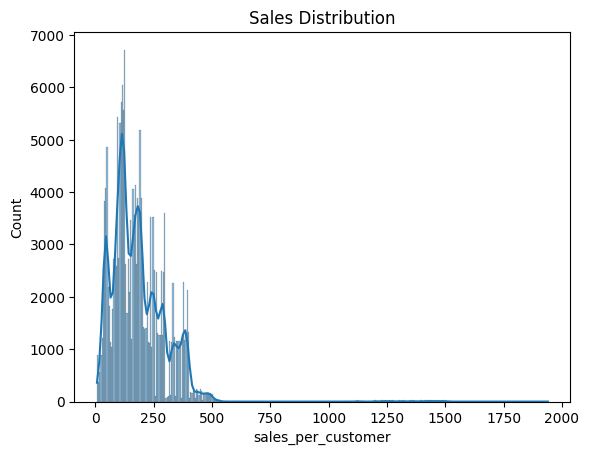

In [34]:
sns.histplot(df['sales_per_customer'], kde=True)
plt.title('Sales Distribution')
plt.show()

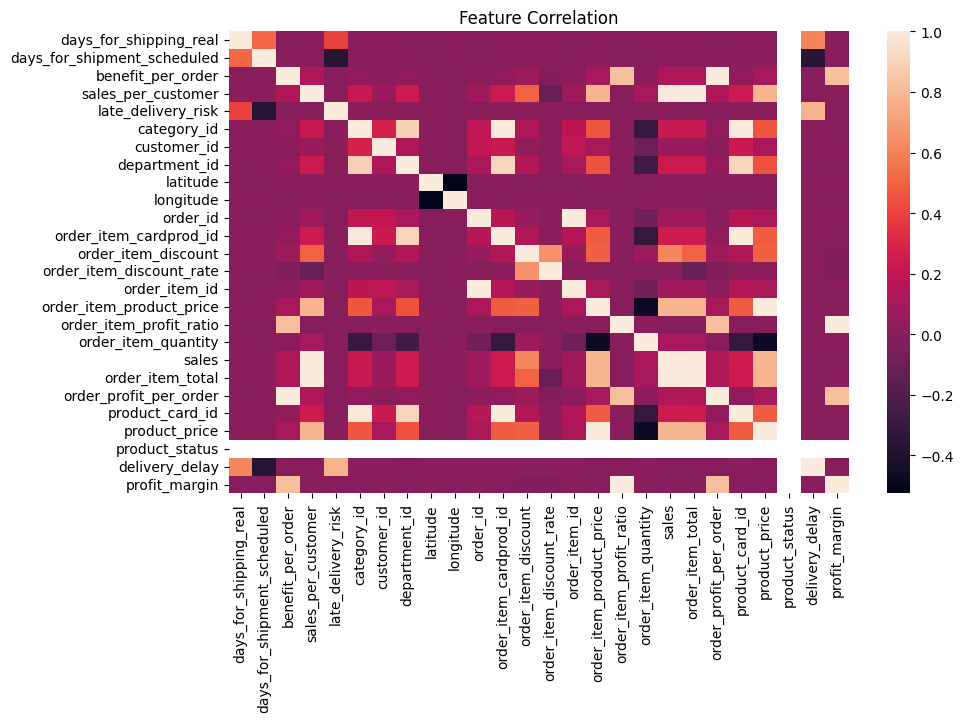

In [35]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=False)
plt.title("Feature Correlation")
plt.show()

## 1. Time Series Analysis — Monthly Revenue & Order Trends

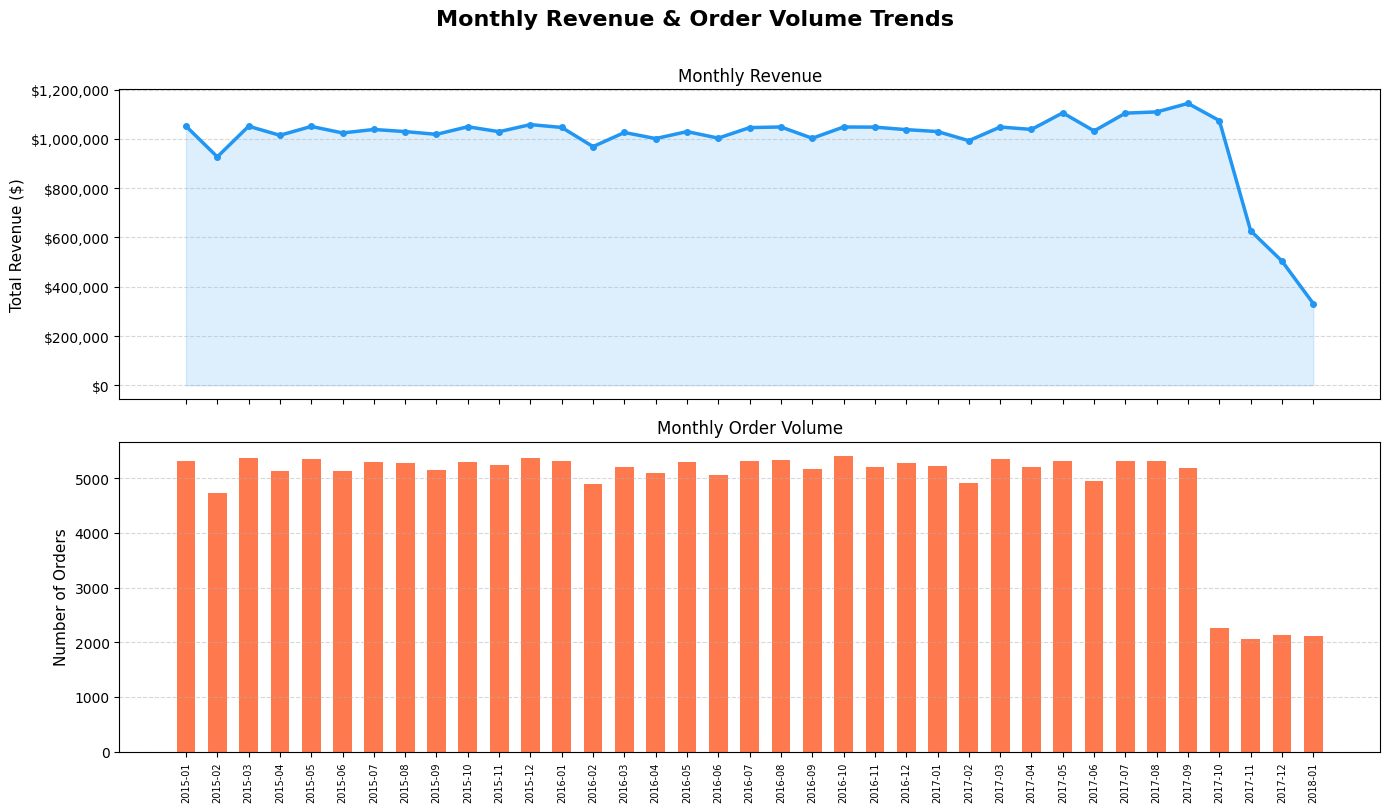

Peak revenue month : 2017-09
Peak orders month  : 2016-10


In [37]:
# Extract time components
df['order_month'] = df['order_date_dateorders'].dt.to_period('M')
df['order_year']  = df['order_date_dateorders'].dt.year
df['order_month_name'] = df['order_date_dateorders'].dt.strftime('%b %Y')

# Monthly aggregations
monthly = df.groupby('order_month').agg(
    total_revenue=('sales', 'sum'),
    total_orders=('order_id', 'count'),
    avg_order_value=('sales', 'mean')
).reset_index()
monthly['order_month'] = monthly['order_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Monthly Revenue & Order Volume Trends', fontsize=16, fontweight='bold', y=1.01)

# Revenue trend
axes[0].plot(monthly['order_month'], monthly['total_revenue'], color='#2196F3', linewidth=2.5, marker='o', markersize=4)
axes[0].fill_between(range(len(monthly)), monthly['total_revenue'], alpha=0.15, color='#2196F3')
axes[0].set_ylabel('Total Revenue ($)', fontsize=11)
axes[0].set_title('Monthly Revenue', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Order volume trend
axes[1].bar(range(len(monthly)), monthly['total_orders'], color='#FF5722', alpha=0.8, width=0.6)
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['order_month'], rotation=90, fontsize=7)
axes[1].set_ylabel('Number of Orders', fontsize=11)
axes[1].set_title('Monthly Order Volume', fontsize=12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('01_time_series.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Peak revenue month : {monthly.loc[monthly['total_revenue'].idxmax(), 'order_month']}")
print(f"Peak orders month  : {monthly.loc[monthly['total_orders'].idxmax(), 'order_month']}")


## 2. Late Delivery Deep Dive

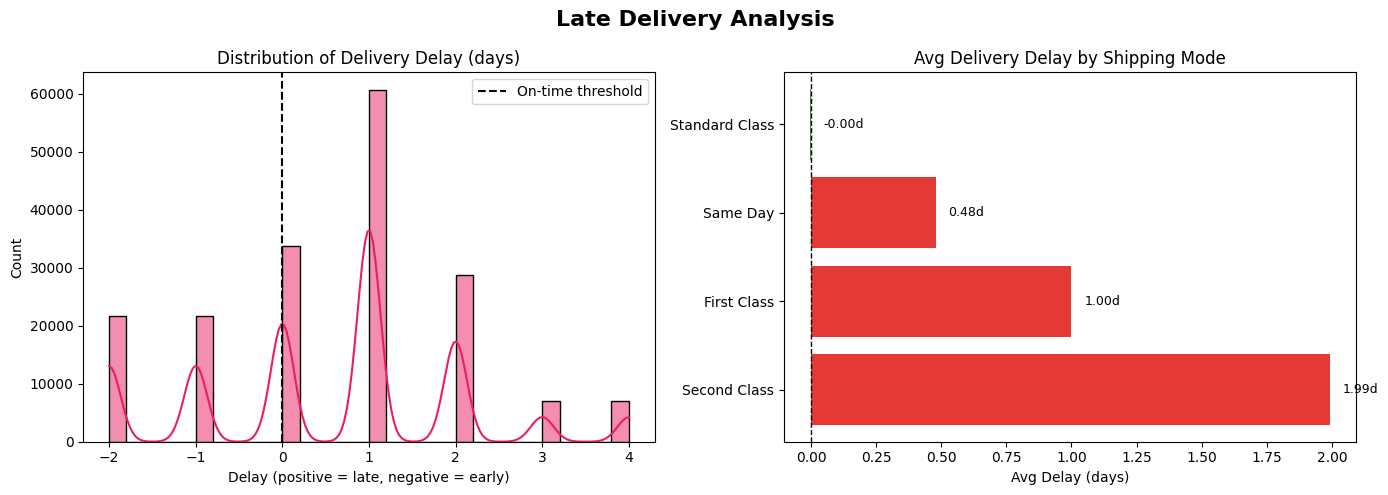

In [38]:
# ---- 2a. Delivery delay distribution ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Late Delivery Analysis', fontsize=16, fontweight='bold')

# Histogram of delivery delay
sns.histplot(df['delivery_delay'], bins=30, kde=True, color='#E91E63', ax=axes[0])
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='On-time threshold')
axes[0].set_title('Distribution of Delivery Delay (days)')
axes[0].set_xlabel('Delay (positive = late, negative = early)')
axes[0].legend()

# Average delay by shipping mode
delay_by_mode = df.groupby('shipping_mode')['delivery_delay'].mean().sort_values(ascending=False)
colors = ['#E53935' if v > 0 else '#43A047' for v in delay_by_mode.values]
axes[1].barh(delay_by_mode.index, delay_by_mode.values, color=colors)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Avg Delivery Delay by Shipping Mode')
axes[1].set_xlabel('Avg Delay (days)')
for i, v in enumerate(delay_by_mode.values):
    axes[1].text(v + 0.05, i, f'{v:.2f}d', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('02_delivery_delay.png', dpi=150, bbox_inches='tight')
plt.show()


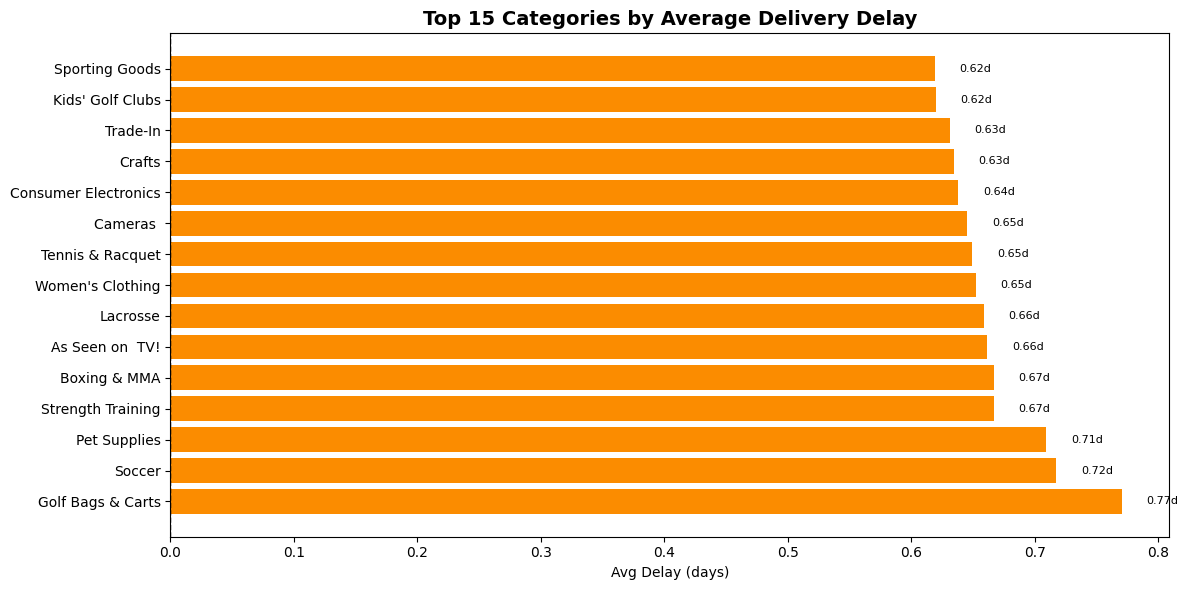

In [39]:
# ---- 2b. Top categories with worst delivery delays ----
category_delay = (
    df.groupby('category_name')['delivery_delay']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

plt.figure(figsize=(12, 6))
colors = ['#E53935' if v > 1 else '#FB8C00' if v > 0 else '#43A047' for v in category_delay['delivery_delay']]
bars = plt.barh(category_delay['category_name'], category_delay['delivery_delay'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title('Top 15 Categories by Average Delivery Delay', fontsize=14, fontweight='bold')
plt.xlabel('Avg Delay (days)')
for bar, val in zip(bars, category_delay['delivery_delay']):
    plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val:.2f}d', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('02b_category_delay.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Profitability Analysis

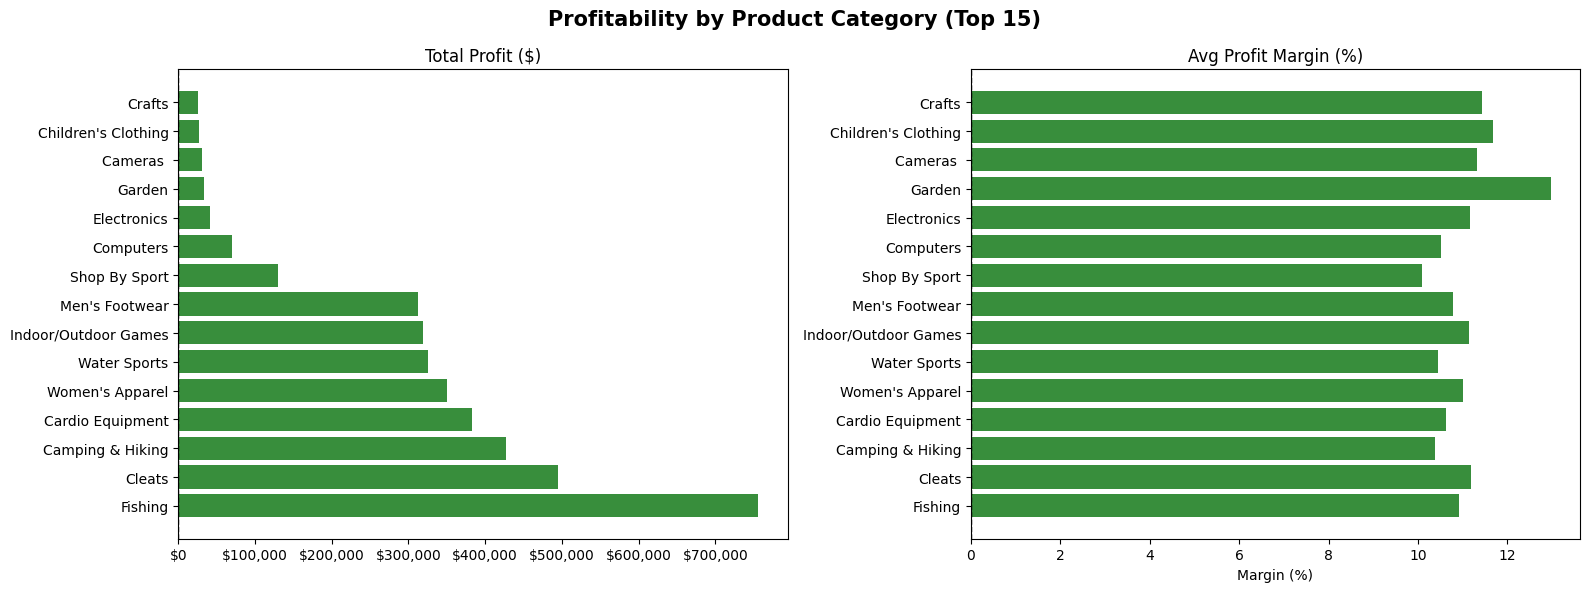

In [40]:
# ---- 3a. Profit by product category ----
cat_profit = (
    df.groupby('category_name')
    .agg(total_profit=('order_profit_per_order', 'sum'),
         avg_margin=('profit_margin', 'mean'),
         order_count=('order_id', 'count'))
    .sort_values('total_profit', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Profitability by Product Category (Top 15)', fontsize=15, fontweight='bold')

# Total profit
colors = ['#388E3C' if v >= 0 else '#D32F2F' for v in cat_profit['total_profit']]
axes[0].barh(cat_profit['category_name'], cat_profit['total_profit'], color=colors)
axes[0].set_title('Total Profit ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)

# Avg profit margin
colors2 = ['#388E3C' if v >= 0 else '#D32F2F' for v in cat_profit['avg_margin']]
axes[1].barh(cat_profit['category_name'], cat_profit['avg_margin'] * 100, color=colors2)
axes[1].set_title('Avg Profit Margin (%)')
axes[1].set_xlabel('Margin (%)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('03a_category_profit.png', dpi=150, bbox_inches='tight')
plt.show()


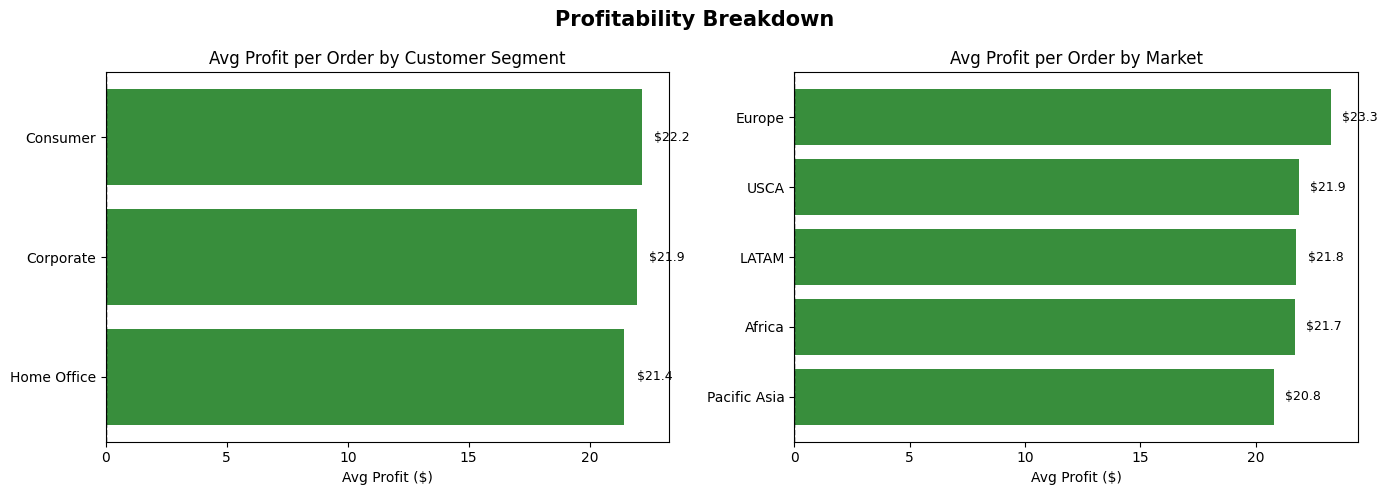

In [41]:
# ---- 3b. Profitability by customer segment & market ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profitability Breakdown', fontsize=15, fontweight='bold')

# By customer segment
seg_profit = df.groupby('customer_segment')['order_profit_per_order'].mean().sort_values()
seg_colors = ['#388E3C' if v >= 0 else '#D32F2F' for v in seg_profit.values]
axes[0].barh(seg_profit.index, seg_profit.values, color=seg_colors)
axes[0].set_title('Avg Profit per Order by Customer Segment')
axes[0].set_xlabel('Avg Profit ($)')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(seg_profit.values):
    axes[0].text(v + 0.5, i, f'${v:.1f}', va='center', fontsize=9)

# By market
mkt_profit = df.groupby('market')['order_profit_per_order'].mean().sort_values()
mkt_colors = ['#388E3C' if v >= 0 else '#D32F2F' for v in mkt_profit.values]
axes[1].barh(mkt_profit.index, mkt_profit.values, color=mkt_colors)
axes[1].set_title('Avg Profit per Order by Market')
axes[1].set_xlabel('Avg Profit ($)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
for i, v in enumerate(mkt_profit.values):
    axes[1].text(v + 0.5, i, f'${v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('03b_segment_market_profit.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Customer Segmentation — RFM Analysis

In [42]:
# ---- RFM Calculation ----
snapshot_date = df['order_date_dateorders'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency   = ('order_date_dateorders', lambda x: (snapshot_date - x.max()).days),
    frequency = ('order_id', 'count'),
    monetary  = ('sales', 'sum')
).reset_index()

# Score each dimension into 4 quartiles (1=worst, 4=best)
rfm['r_score'] = pd.qcut(rfm['recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['m_score'] = pd.qcut(rfm['monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

# Segment labels
def rfm_label(score):
    if score >= 10: return 'Champions'
    elif score >= 8: return 'Loyal Customers'
    elif score >= 6: return 'Potential Loyalists'
    elif score >= 4: return 'At Risk'
    else: return 'Lost'

rfm['segment'] = rfm['rfm_score'].apply(rfm_label)
print(rfm['segment'].value_counts())
rfm.head()


segment
Potential Loyalists    9451
Loyal Customers        5164
Champions              3583
At Risk                2380
Lost                     74
Name: count, dtype: int64


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,segment
0,1,793,1,499.950012,1,1,2,4,At Risk
1,2,137,10,1819.730034,3,3,3,9,Loyal Customers
2,3,230,18,3537.680094,2,4,4,10,Champions
3,4,381,14,1719.630030,1,3,3,7,Potential Loyalists
4,5,458,7,1274.750023,1,2,2,5,At Risk


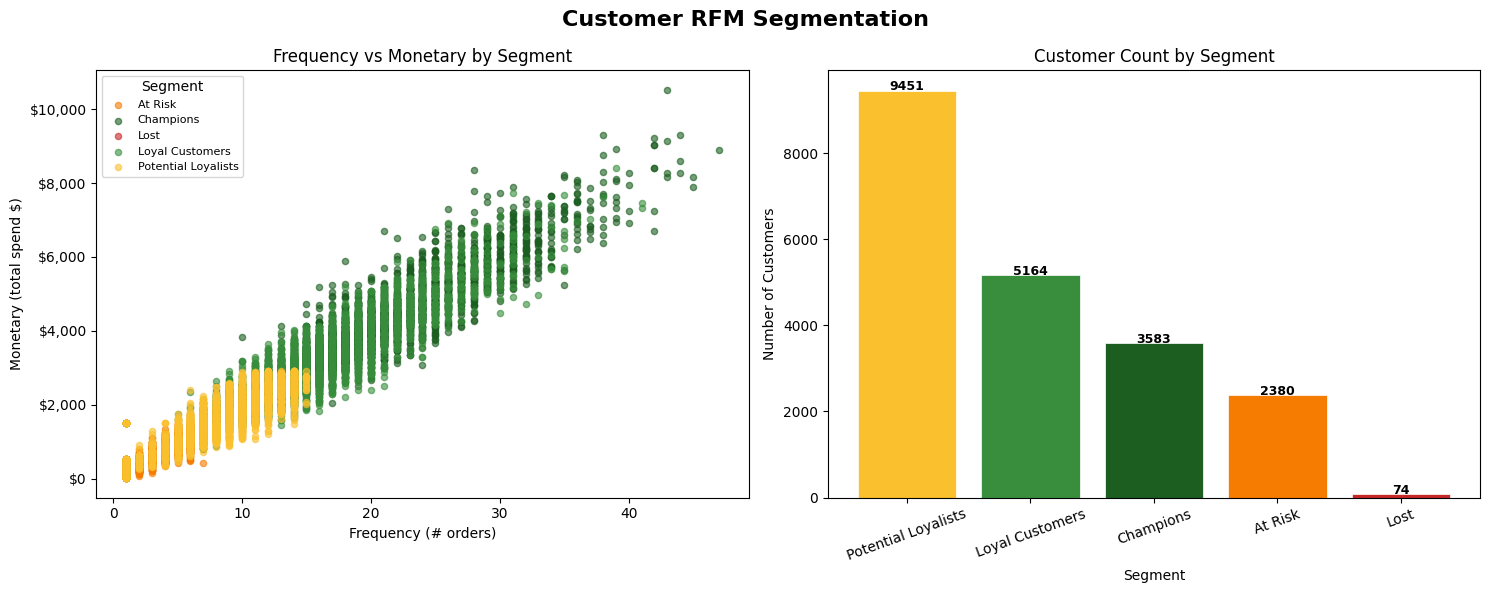

In [43]:
# ---- RFM Visualisation ----
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer RFM Segmentation', fontsize=16, fontweight='bold')

# Scatter: Frequency vs Monetary coloured by segment
palette = {
    'Champions': '#1B5E20',
    'Loyal Customers': '#388E3C',
    'Potential Loyalists': '#FBC02D',
    'At Risk': '#F57C00',
    'Lost': '#C62828'
}
for seg, grp in rfm.groupby('segment'):
    axes[0].scatter(grp['frequency'], grp['monetary'], label=seg,
                    alpha=0.6, s=20, color=palette[seg])
axes[0].set_xlabel('Frequency (# orders)')
axes[0].set_ylabel('Monetary (total spend $)')
axes[0].set_title('Frequency vs Monetary by Segment')
axes[0].legend(title='Segment', fontsize=8)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Bar chart: segment distribution
seg_counts = rfm['segment'].value_counts()
seg_colors = [palette[s] for s in seg_counts.index]
axes[1].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Customer Count by Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(seg_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('04_rfm.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Top & Bottom Performers

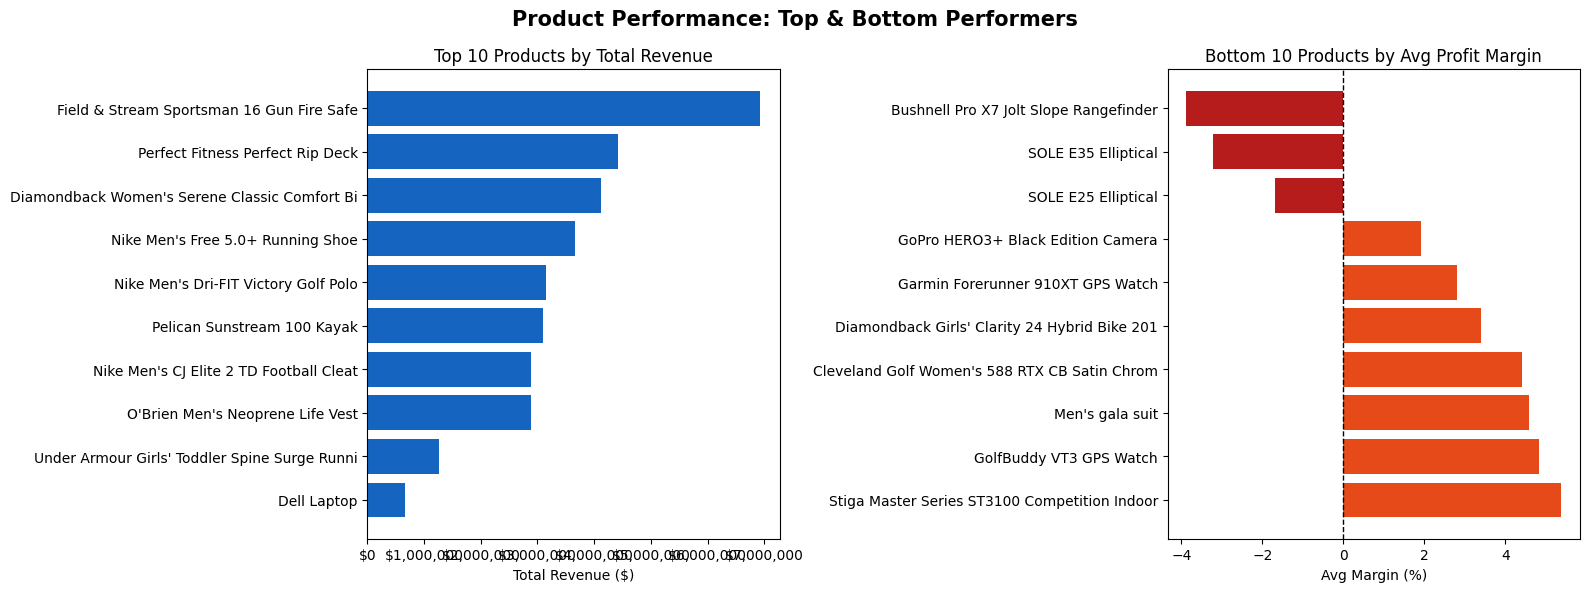

In [44]:
# ---- Top 10 by Revenue vs Bottom 10 by Profit Margin ----
product_stats = (
    df.groupby('product_name')
    .agg(total_revenue=('sales', 'sum'),
         avg_margin=('profit_margin', 'mean'),
         orders=('order_id', 'count'))
    .reset_index()
)

top10_rev    = product_stats.nlargest(10, 'total_revenue')
bottom10_mgn = product_stats[product_stats['orders'] > 5].nsmallest(10, 'avg_margin')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Performance: Top & Bottom Performers', fontsize=15, fontweight='bold')

# Top 10 by Revenue
axes[0].barh(top10_rev['product_name'], top10_rev['total_revenue'], color='#1565C0')
axes[0].set_title('Top 10 Products by Total Revenue')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()

# Bottom 10 by Margin
colors = ['#B71C1C' if v < 0 else '#E64A19' for v in bottom10_mgn['avg_margin']]
axes[1].barh(bottom10_mgn['product_name'], bottom10_mgn['avg_margin'] * 100, color=colors)
axes[1].set_title('Bottom 10 Products by Avg Profit Margin')
axes[1].set_xlabel('Avg Margin (%)')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('05_top_bottom_products.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Geographic (Regional) Analysis

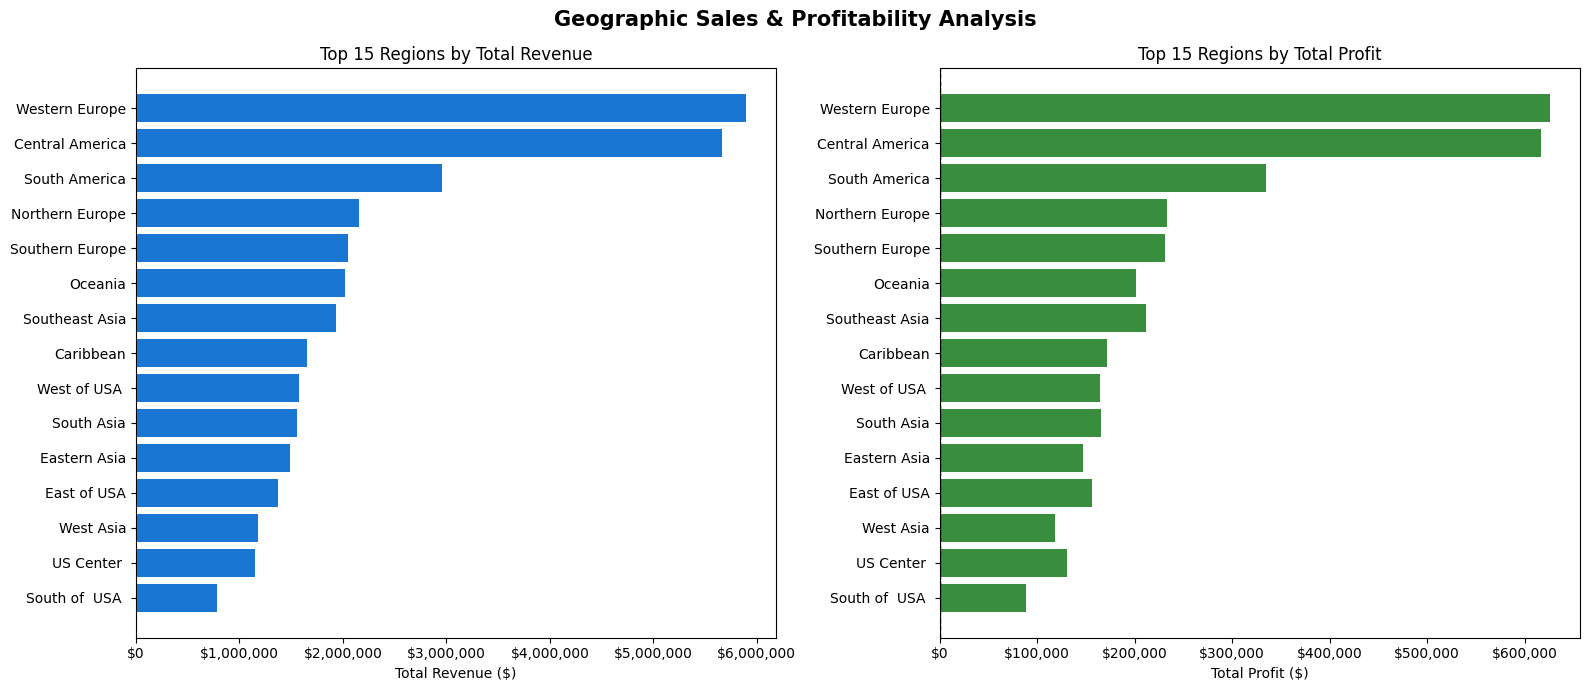

In [45]:
# ---- Revenue & Profit by Region / Market ----
geo = (
    df.groupby(['market', 'order_region'])
    .agg(total_revenue=('sales', 'sum'),
         total_profit=('order_profit_per_order', 'sum'),
         order_count=('order_id', 'count'))
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

# Top 15 regions by revenue
top_regions = geo.head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Geographic Sales & Profitability Analysis', fontsize=15, fontweight='bold')

# Revenue by region
axes[0].barh(top_regions['order_region'], top_regions['total_revenue'], color='#1976D2')
axes[0].set_title('Top 15 Regions by Total Revenue')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].invert_yaxis()

# Profit by region
profit_colors = ['#388E3C' if v > 0 else '#C62828' for v in top_regions['total_profit']]
axes[1].barh(top_regions['order_region'], top_regions['total_profit'], color=profit_colors)
axes[1].set_title('Top 15 Regions by Total Profit')
axes[1].set_xlabel('Total Profit ($)')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('06_geo_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


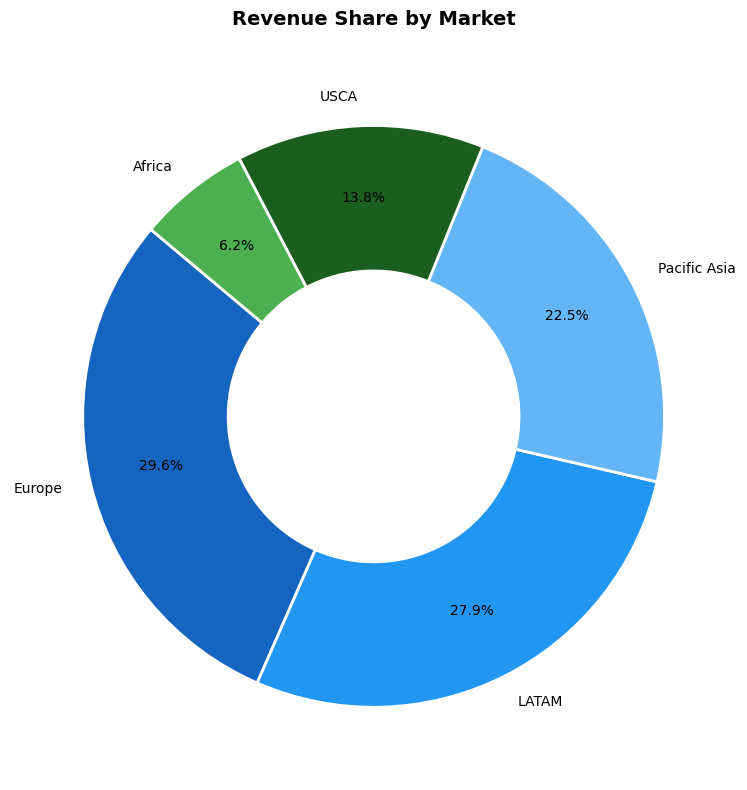

In [46]:
# ---- Revenue by Market (Pie) ----
market_rev = df.groupby('market')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 8))
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2)
colors_pie = ['#1565C0','#2196F3','#64B5F6','#1B5E20','#4CAF50','#FF8F00']
plt.pie(market_rev.values, labels=market_rev.index, autopct='%1.1f%%',
        colors=colors_pie[:len(market_rev)], wedgeprops=wedge_props,
        pctdistance=0.75, startangle=140)
plt.title('Revenue Share by Market', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('06b_market_pie.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Summary Dashboard — All Key Insights in One View

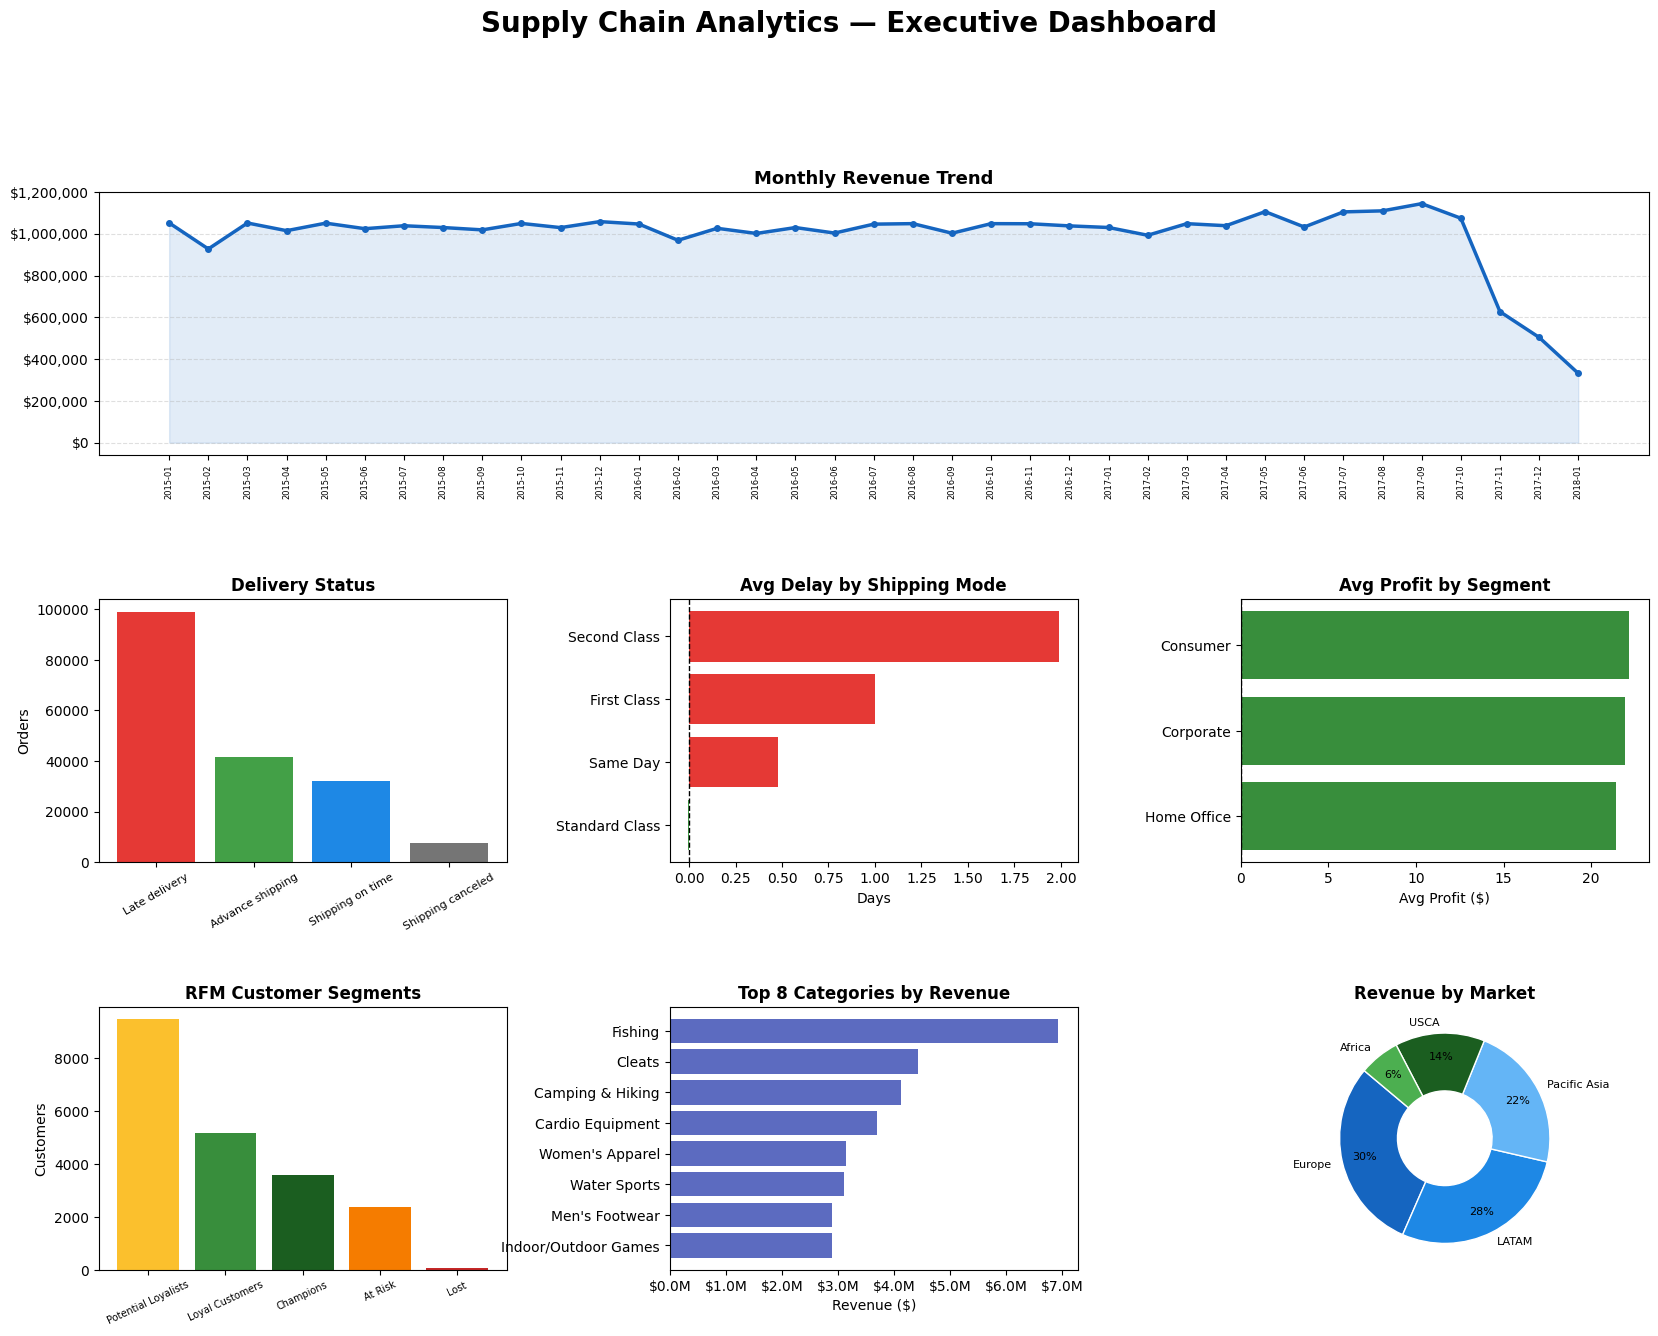

✅ Dashboard saved as 07_dashboard.png


In [47]:
# ---- Master Dashboard ----
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Supply Chain Analytics — Executive Dashboard', fontsize=20, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.4)

# ── Panel 1: Monthly Revenue (top full-width) ──────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly['order_month'], monthly['total_revenue'], color='#1565C0',
         linewidth=2.5, marker='o', markersize=4)
ax1.fill_between(range(len(monthly)), monthly['total_revenue'], alpha=0.12, color='#1565C0')
ax1.set_title('Monthly Revenue Trend', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['order_month'], rotation=90, fontsize=6)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Panel 2: Delivery Status ───────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ds_counts = df['delivery_status'].value_counts()
ds_colors = {'Late delivery':'#E53935','Advance shipping':'#43A047',
             'Shipping on time':'#1E88E5','Shipping canceled':'#757575'}
bar_colors = [ds_colors.get(s, '#90A4AE') for s in ds_counts.index]
ax2.bar(ds_counts.index, ds_counts.values, color=bar_colors)
ax2.set_title('Delivery Status', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=30, labelsize=8)
ax2.set_ylabel('Orders')

# ── Panel 3: Avg Delay by Shipping Mode ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
delay_mode = df.groupby('shipping_mode')['delivery_delay'].mean().sort_values()
c3 = ['#E53935' if v > 0 else '#43A047' for v in delay_mode.values]
ax3.barh(delay_mode.index, delay_mode.values, color=c3)
ax3.axvline(0, color='black', linestyle='--', linewidth=1)
ax3.set_title('Avg Delay by Shipping Mode', fontsize=12, fontweight='bold')
ax3.set_xlabel('Days')

# ── Panel 4: Profit by Customer Segment ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
seg = df.groupby('customer_segment')['order_profit_per_order'].mean().sort_values()
c4 = ['#388E3C' if v >= 0 else '#D32F2F' for v in seg.values]
ax4.barh(seg.index, seg.values, color=c4)
ax4.axvline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title('Avg Profit by Segment', fontsize=12, fontweight='bold')
ax4.set_xlabel('Avg Profit ($)')

# ── Panel 5: RFM Segment Distribution ─────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
seg_c = rfm['segment'].value_counts()
p = {'Champions':'#1B5E20','Loyal Customers':'#388E3C',
     'Potential Loyalists':'#FBC02D','At Risk':'#F57C00','Lost':'#C62828'}
ax5.bar(seg_c.index, seg_c.values, color=[p.get(s,'#90A4AE') for s in seg_c.index])
ax5.set_title('RFM Customer Segments', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=25, labelsize=7)
ax5.set_ylabel('Customers')

# ── Panel 6: Top 8 Categories by Revenue ─────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
top_cats = df.groupby('category_name')['sales'].sum().nlargest(8).sort_values()
ax6.barh(top_cats.index, top_cats.values, color='#5C6BC0')
ax6.set_title('Top 8 Categories by Revenue', fontsize=12, fontweight='bold')
ax6.set_xlabel('Revenue ($)')
ax6.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))

# ── Panel 7: Market Revenue Share ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
mkt = df.groupby('market')['sales'].sum().sort_values(ascending=False)
c7 = ['#1565C0','#1E88E5','#64B5F6','#1B5E20','#4CAF50','#FF8F00']
ax7.pie(mkt.values, labels=mkt.index, autopct='%1.0f%%',
        colors=c7[:len(mkt)], wedgeprops=dict(width=0.55, edgecolor='white'),
        pctdistance=0.78, textprops={'fontsize': 8}, startangle=140)
ax7.set_title('Revenue by Market', fontsize=12, fontweight='bold')

plt.savefig('07_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Dashboard saved as 07_dashboard.png")
